## Logistic Regression example by using the Flamby Heart Disease dataset.

The Flamby heart disease dataset uses 4 different centers with 13 features and a target from 0-4, 0 representing non-sick and 1-4 representing the sickness level.

In the preprocessing below, I removed the three columns (10-12) which had too many NaNs, one-hot encoded columns 2 and 6, which added another 3 columns for one-hot encoding and changed the labels into binary (0 sick and 1 non-sick) to improve training performance.

The same logic can be seen in Fedbiomed tutorial for Fed Heart Disease: https://github.com/owkin/FLamby/blob/main/flamby/datasets/fed_heart_disease/dataset.py 

### Do preprocessing on the CSVs before adding them to the node

This step is necessary for dropping the NaN values/columns and normalizing the samples.

**Important Note:** I normalized each center with its own mean and std; however I used the global mean and std when normalizing the validation dataset, as it yielded better performance. Normalizing within each center seemed to be training well, yet if we have time it must be interesting to normalize globally for training and see if the model is performing better.

In [183]:
import numpy as np
import pandas as pd

in_path = "/mnt/c/Users/adincer/Desktop/fedbiomed/data/va.csv"

out_before_norm = "/mnt/c/Users/adincer/Desktop/fedbiomed/data/va_clean_onehot_binary_BEFORE_norm.csv"
out_after_norm  = "/mnt/c/Users/adincer/Desktop/fedbiomed/data/va_clean_onehot_binary_AFTER_norm.csv"

# load + clean
df = pd.read_csv(in_path, header=0)
df = df.replace("?", np.nan).drop(df.columns[[10, 11, 12]], axis=1).dropna(axis=0)
df = df.apply(pd.to_numeric)

label_col = df.columns[-1]

# one-hot encode categorical columns 2 (cp) and 6 (restecg)
df = pd.get_dummies(df, columns=df.columns[[2, 6]], drop_first=True)

# convert dummy bool columns True/False -> 0/1
bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype(np.int64)

# binarize label 0 vs >0 -> 0/1
df[label_col] = (df[label_col] > 0).astype(np.int64)

# ensure label is the LAST column
feature_cols = [c for c in df.columns if c != label_col]
df = df[feature_cols + [label_col]]

# save BEFORE normalization
df.to_csv(out_before_norm, header=False, index=False)

# normalize features only (z-score)
mu = df[feature_cols].mean()
sigma = df[feature_cols].std(ddof=0).replace(0, 1)
df_norm = df.copy()
df_norm[feature_cols] = (df_norm[feature_cols] - mu) / sigma

# save AFTER normalization
df_norm.to_csv(out_after_norm, header=False, index=False)

print("Saved:")
print(" - Before normalization:", out_before_norm)
print(" - After normalization :", out_after_norm)
print("Dummy bool cols converted:", list(bool_cols))

Saved:
 - Before normalization: /mnt/c/Users/adincer/Desktop/fedbiomed/data/va_clean_onehot_binary_BEFORE_norm.csv
 - After normalization : /mnt/c/Users/adincer/Desktop/fedbiomed/data/va_clean_onehot_binary_AFTER_norm.csv
Dummy bool cols converted: ['4_2', '4_3', '4_4', '1.1_1', '1.1_2']


Check the class distribution in centers to avoid issues on the training. In Flamby Heart Disease dataset, there is an obvious class imbalance on the 3rd center (Switzerland center).

In [187]:
import numpy as np
import pandas as pd

def check_class_imbalance(y, *, name="y"):
    y = np.asarray(y)
    vals, counts = np.unique(y, return_counts=True)
    total = counts.sum()

    report = pd.DataFrame({
        "class": vals,
        "count": counts,
        "pct": (counts / total * 100).round(2),
    }).sort_values("count", ascending=False)

    print(f"\nClass distribution for {name} (n={total}):")
    print(report.to_string(index=False))

    maj = counts.max()
    min_ = counts.min()
    print(f"\nMajority: {maj} ({maj/total:.2%})")
    print(f"Minority: {min_} ({min_/total:.2%})")
    print(f"Imbalance ratio (maj/min): {maj / max(min_, 1):.2f}x")

    return report

report = check_class_imbalance(pd.read_csv("/mnt/c/Users/adincer/Desktop/fedbiomed/data/switzerland_clean_onehot_binary_AFTER_norm.csv", header=None).iloc[:, 13].to_numpy(), name="target")
print(df.shape)


Class distribution for target (n=46):
 class  count   pct
     1     45 97.83
     0      1  2.17

Majority: 45 (97.83%)
Minority: 1 (2.17%)
Imbalance ratio (maj/min): 45.00x
(129, 14)


### Defining the training plan with FedSGDClassifier and a Custom Accuracy Metric to improve performance

In [127]:
from fedbiomed.common.training_plans import FedSGDClassifier
from fedbiomed.common.dataset import TabularDataset
from fedbiomed.common.datamanager import DataManager

class SGDRegressorTrainingPlan(FedSGDClassifier):
    def init_dependencies(self):
        """Define additional dependencies."""
        return [
                "from fedbiomed.common.dataset import TabularDataset",
                "from sklearn.metrics import balanced_accuracy_score",
                "import numpy as np",
        ]

    def training_data(self):
        dataset = TabularDataset(input_columns=list(range(0,13)), target_columns=13)
        return DataManager(dataset=dataset)

    def testing_step(self, data, target):
        preds = self.model().predict(data)
        balanced_accuracy = balanced_accuracy_score(y_pred=preds, y_true=target)
        print("Pred: ", preds)
        print("Target: ", target)
        return balanced_accuracy

In [128]:
model_args = {
    'n_features':13,
    'n_classes':2,
    'loss': 'log_loss',
    'learning_rate': "constant", 
    'eta0': 0.01,
    # 'alpha': 1e-4,
    # 'penalty': "l2",
    # 'random_state':RANDOM_SEED,
}

training_args = {
    # 'shuffle': True,
    'loader_args': { 'batch_size': 16, },
    'epochs': 1,
    'dry_run': False,
    # 'log_interval': 2,
    'test_ratio' : 0.2,
    'test_batch_size': 16,
    'test_on_global_updates': True,
    'test_on_local_updates': True,
    # 'batch_maxnum': 10 # Fast pass for development : only use ( batch_maxnum * batch_size ) samples
}

In [129]:
from fedbiomed.researcher.federated_workflows import Experiment
from fedbiomed.researcher.aggregators.fedavg import FedAverage

tags = ['flamby']
num_rounds = 30

exp = Experiment(tags=tags,
                 model_args=model_args,
                 training_plan_class=SGDRegressorTrainingPlan,
                 training_args=training_args,
                 round_limit=num_rounds,
                 aggregator=FedAverage(),
                )

2026-02-20 11:32:47,664 fedbiomed INFO - Updating training data. This action will update FederatedDataset, and the nodes that will participate to the experiment.

2026-02-20 11:32:47,668 fedbiomed INFO - Node NODE_af806b22-1946-4df5-be06-810ce90b3986 is disconnected. Discard message.

2026-02-20 11:32:47,685 fedbiomed DEBUG - Node: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 polling for the tasks

2026-02-20 11:32:47,689 fedbiomed DEBUG - Node: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 polling for the tasks

2026-02-20 11:32:47,691 fedbiomed INFO - Node selected for training -> Default Node Alias
Node ID is -> NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2

2026-02-20 11:32:47,692 fedbiomed INFO - Node selected for training -> Default Node Alias
Node ID is -> NODE_89269fb8-e88f-447b-bf40-6cff09f06a75

2026-02-20 11:32:47,713 fedbiomed DEBUG - Model file has been saved: /mnt/c/Users/adincer/Desktop/fedbiomed/fbm-researcher/var/experiments/Experiment_0995/model_23c661af-1c9c-4466-baf6-ded97cb76dfc.py

2026-02-20 11:32:47,753 fedbiomed WARNING - Option share_persistent_buffers is not supported in SKLearnTrainingPlan, it will be ignored.

2026-02-20 11:32:47,755 fedbiomed DEBUG - Using native Sklearn Optimizer

In [130]:
exp.run()

2026-02-20 11:32:49,270 fedbiomed INFO - Sampled nodes in round 0 ['NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2', 'NODE_89269fb8-e88f-447b-bf40-6cff09f06a75']

2026-02-20 11:32:49,288 fedbiomed INFO - Sending request 
					 To: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 
					 Request: : TRAIN
 -----------------------------------------------------------------

2026-02-20 11:32:49,289 fedbiomed INFO - Sending request 
					 To: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 
					 Request: : TRAIN
 -----------------------------------------------------------------

2026-02-20 11:32:49,308 fedbiomed DEBUG - Node: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 polling for the tasks

2026-02-20 11:32:49,311 fedbiomed DEBUG - Node: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 polling for the tasks

...

2026-02-20 11:33:31,309 fedbiomed INFO - VALIDATION ON GLOBAL UPDATES 
					 NODE_ID: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 
					 Node Name: Default Node Alias 
					 Round 31 | Iteration: 1/4 (25%) | Samples: 16/52
 					 Custom: 0.783333 
					 ---------

2026-02-20 11:33:31,316 fedbiomed INFO - VALIDATION ON GLOBAL UPDATES 
					 NODE_ID: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 
					 Node Name: Default Node Alias 
					 Round 31 | Iteration: 1/4 (25%) | Samples: 16/60
 					 Custom: 0.817460 
					 ---------

2026-02-20 11:33:31,439 fedbiomed INFO - VALIDATION ON GLOBAL UPDATES 
					 NODE_ID: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 
					 Node Name: Default Node Alias 
					 Round 31 | Iteration: 4/4 (100%) | Samples: 52/52
 					 Custom: 1.000000 
					 ---------

2026-02-20 11:33:31,465 fedbiomed INFO - VALIDATION ON GLOBAL UPDATES 
					 NODE_ID: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 
					 Node Name: Default Node Alias 
					 Round 31 | Iteration: 4/4 (100%) | Samples: 60/60
 					 Custom: 0.916667 
					 ---------

30

### Plot the results

I also added different plots for different parameters. I believe due to the dataset being rather small, the model trains better with less epochs and more rounds.

In [131]:
import numpy as np

nodes = exp.monitor()._metric_store.keys()
train_losses = {}
for node in nodes:
  train_losses[node] = list()
  for round in exp.monitor()._metric_store[node]['training']['Loss log_loss'].keys():
    round_loss = exp.monitor()._metric_store[node]['training']['Loss log_loss'][round]['values']
    train_losses[node].append(np.mean(round_loss))

balanced_accuracies = {}
for node in nodes:
    balanced_accuracies[node] = list()
    for round in exp.monitor()._metric_store[node]['testing_global_updates']['Custom'].keys():
      round_accs = exp.monitor()._metric_store[node]['testing_global_updates']['Custom'][round]['values']
      balanced_accuracies[node].append(np.mean(round_accs))

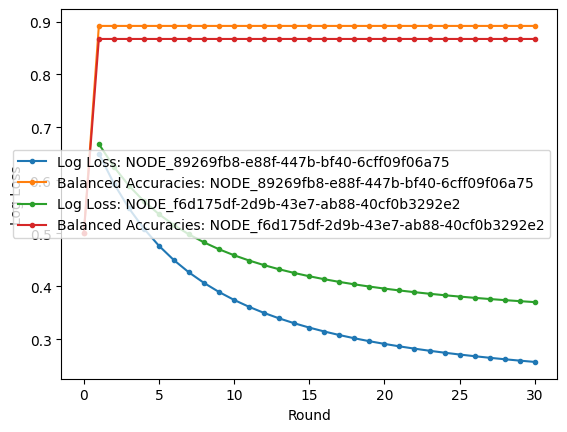

In [132]:
import matplotlib.pyplot as plt

for node in nodes:
  plt.plot(range(1,exp.round_limit()+1), train_losses[node], '.-', label=f'Log Loss: {node}')
  plt.plot(range(exp.round_limit()+1), balanced_accuracies[node], '.-', label=f'Balanced Accuracies: {node}')
_ = plt.xlabel('Round')
_ = plt.ylabel('Log Loss')
plt.legend()

### Different Plots

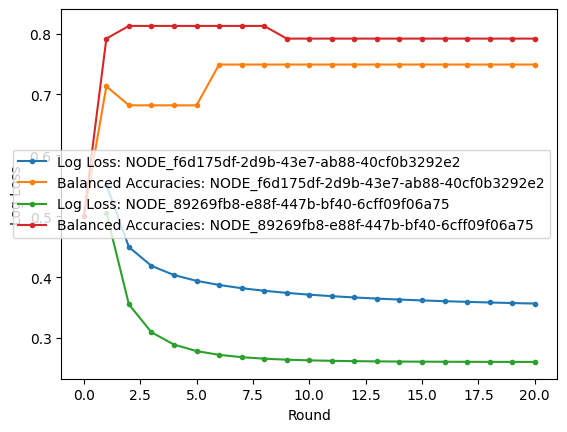

In [122]:
# Epochs 10
# Rounds 20

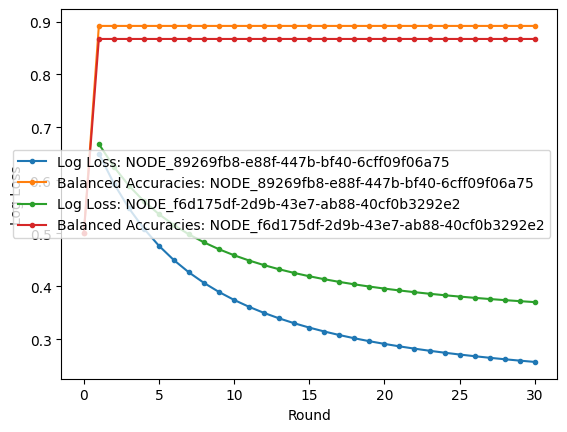

In [132]:
# Epochs 1
# Rounds 30

### Validation on a Third Center/Dataset

For this, I compared the results for 

1. When the third center is normalized using its own mean and std
2. When the third center is normalized using the mean and std from the two centers used for training

It seems to perform slightly

In [169]:
model = exp.training_plan().model()

Using the Csv file, normalized with its own mean and std.

In [ ]:
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report

path = "/mnt/c/Users/adincer/Desktop/fedbiomed/data/va_clean_onehot_binary_AFTER_norm.csv"

df = pd.read_csv(path, header=None)

y_true = df.iloc[:, -1].to_numpy().astype(int)
X = df.drop(df.columns[-1], axis=1).to_numpy().astype(np.float32)

# Predict
y_pred = model.predict(X)

bal_acc = balanced_accuracy_score(y_true, y_pred)
print("Balanced accuracy:", bal_acc)
print("\nConfusion matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification report:\n", classification_report(y_true, y_pred, digits=4))

When re-normalized using the mean and std of the training centers.

In [188]:
cleveland_path = "/mnt/c/Users/adincer/Desktop/fedbiomed/data/cleveland_clean_onehot_binary_BEFORE_norm.csv"
hungarian_path = "/mnt/c/Users/adincer/Desktop/fedbiomed/data/hungarian_clean_onehot_binary_BEFORE_norm.csv"
third_path     = "/mnt/c/Users/adincer/Desktop/fedbiomed/data/va_clean_onehot_binary_BEFORE_norm.csv"

# out_third_norm = "/mnt/data/HeartDiseaseTrain-Test-normalized_like_trainCenters.csv"

def load_xy(csv_path, header=None, label_col=-1):
    df = pd.read_csv(csv_path, header=header)
    df = df.apply(pd.to_numeric, errors="coerce").dropna(axis=0)
    y = df.iloc[:, label_col].to_numpy().astype(np.int64)
    X = df.drop(df.columns[label_col], axis=1).to_numpy().astype(np.float32)
    return df, X, y

# Load train centers
df_c, X_c, y_c = load_xy(cleveland_path, header=None, label_col=-1)
df_h, X_h, y_h = load_xy(hungarian_path, header=None, label_col=-1)

# Check same feature dimensionality
if X_c.shape[1] != X_h.shape[1]:
    raise ValueError(f"Feature mismatch: Cleveland has {X_c.shape[1]} features, Hungary has {X_h.shape[1]}.")

# Compute μ/σ on combined train-center features
X_train = np.vstack([X_c, X_h])
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma[sigma == 0] = 1.0  # avoid divide-by-zero for constant columns

# Load third center
df_t, X_t, y_t = load_xy(third_path, header=None, label_col=-1)

if X_t.shape[1] != mu.shape[0]:
    raise ValueError(f"Third dataset feature count {X_t.shape[1]} != train mu length {mu.shape[0]}.")

# Apply train μ/σ to third dataset
X_t_norm = (X_t - mu) / sigma

# Rebuild dataframe with label last
df_out = pd.DataFrame(X_t_norm)
df_out[len(df_out.columns)] = y_t  # append label as last column

# df_out.to_csv(out_third_norm, header=False, index=False)
df_out

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-0.806332,0.645822,-0.120813,-0.660959,-0.357771,-0.747550,-0.690246,-0.779081,-0.58008,-0.552771,1.092956,3.171565,-0.612870,0
1,0.948271,0.645822,-0.007343,-0.507164,-0.357771,-0.201684,1.448758,0.609088,-0.58008,-0.552771,1.092956,3.171565,-0.612870,1
2,0.399958,0.645822,0.560007,-0.336281,-0.357771,0.176223,1.448758,1.534533,-0.58008,-0.552771,1.092956,3.171565,-0.612870,1
3,1.606247,0.645822,-1.255512,-0.592605,2.795085,-1.923261,1.448758,0.423998,-0.58008,1.809068,-0.914950,-0.315302,1.631667,0
4,1.606247,0.645822,-0.688162,-4.232408,-0.357771,-1.041478,-0.690246,-1.241804,-0.58008,1.809068,-0.914950,3.171565,-0.612870,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,1.167596,0.645822,1.467766,-1.327401,-0.357771,-0.285664,1.448758,-0.779081,-0.58008,-0.552771,1.092956,3.171565,-0.612870,1
125,-0.587006,0.645822,0.106127,1.064957,-0.357771,-0.789540,-0.690246,-0.779081,-0.58008,-0.552771,1.092956,-0.315302,-0.612870,1
126,0.290295,-1.548415,-0.291018,1.457987,2.795085,0.386171,-0.690246,-0.779081,-0.58008,-0.552771,1.092956,3.171565,-0.612870,1
127,0.399958,0.645822,-0.574693,-0.421723,2.795085,-1.881271,-0.690246,-0.779081,-0.58008,-0.552771,1.092956,3.171565,-0.612870,1


In [ ]:
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report

# path = "/mnt/c/Users/adincer/Desktop/fedbiomed/data/va_clean_onehot_binary_AFTER_norm.csv"
path = "/mnt/c/Users/adincer/Desktop/fedbiomed/data/va_clean_onehot_binary_AFTER_norm.csv"

# df = pd.read_csv(path, header=None)
df = df_out

y_true = df.iloc[:, -1].to_numpy().astype(int)
X = df.drop(df.columns[-1], axis=1).to_numpy().astype(np.float32)

# Predict
y_pred = model.predict(X)

bal_acc = balanced_accuracy_score(y_true, y_pred)
print("Balanced accuracy:", bal_acc)
print("\nConfusion matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification report:\n", classification_report(y_true, y_pred, digits=4))

Balanced accuracy: 0.6074137931034482

Confusion matrix:
 [[10 19]
 [13 87]]

Classification report:
               precision    recall  f1-score   support

           0     0.4348    0.3448    0.3846        29
           1     0.8208    0.8700    0.8447       100

    accuracy                         0.7519       129
   macro avg     0.6278    0.6074    0.6146       129
weighted avg     0.7340    0.7519    0.7412       129



2026-02-20 13:24:44,517 fedbiomed DEBUG - Node: NODE_f6d175df-2d9b-43e7-ab88-40cf0b3292e2 polling for the tasks

2026-02-20 13:24:57,065 fedbiomed DEBUG - Node: NODE_89269fb8-e88f-447b-bf40-6cff09f06a75 polling for the tasks